# Case Study 7: Denoising Autoencoder
**Objective:** Build a Denoising Autoencoder (DAE) on MNIST — add noise to images and train the model to reconstruct clean versions.
**Covers:** Noisy data preparation, autoencoder design, reconstruction quality, compression explanation.

In [1]:
!pip install torch torchvision matplotlib numpy scikit-learn --quiet

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torchvision.utils import make_grid
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


## 1. Load MNIST & Noisy Data Preparation

In [3]:
transform = transforms.Compose([transforms.ToTensor()])
train_ds  = datasets.MNIST('.', train=True,  download=True, transform=transform)
test_ds   = datasets.MNIST('.', train=False, download=True, transform=transform)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=128, shuffle=False)
print(f'Train: {len(train_ds)}, Test: {len(test_ds)}')

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.04MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 134kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.22MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.97MB/s]

Train: 60000, Test: 10000


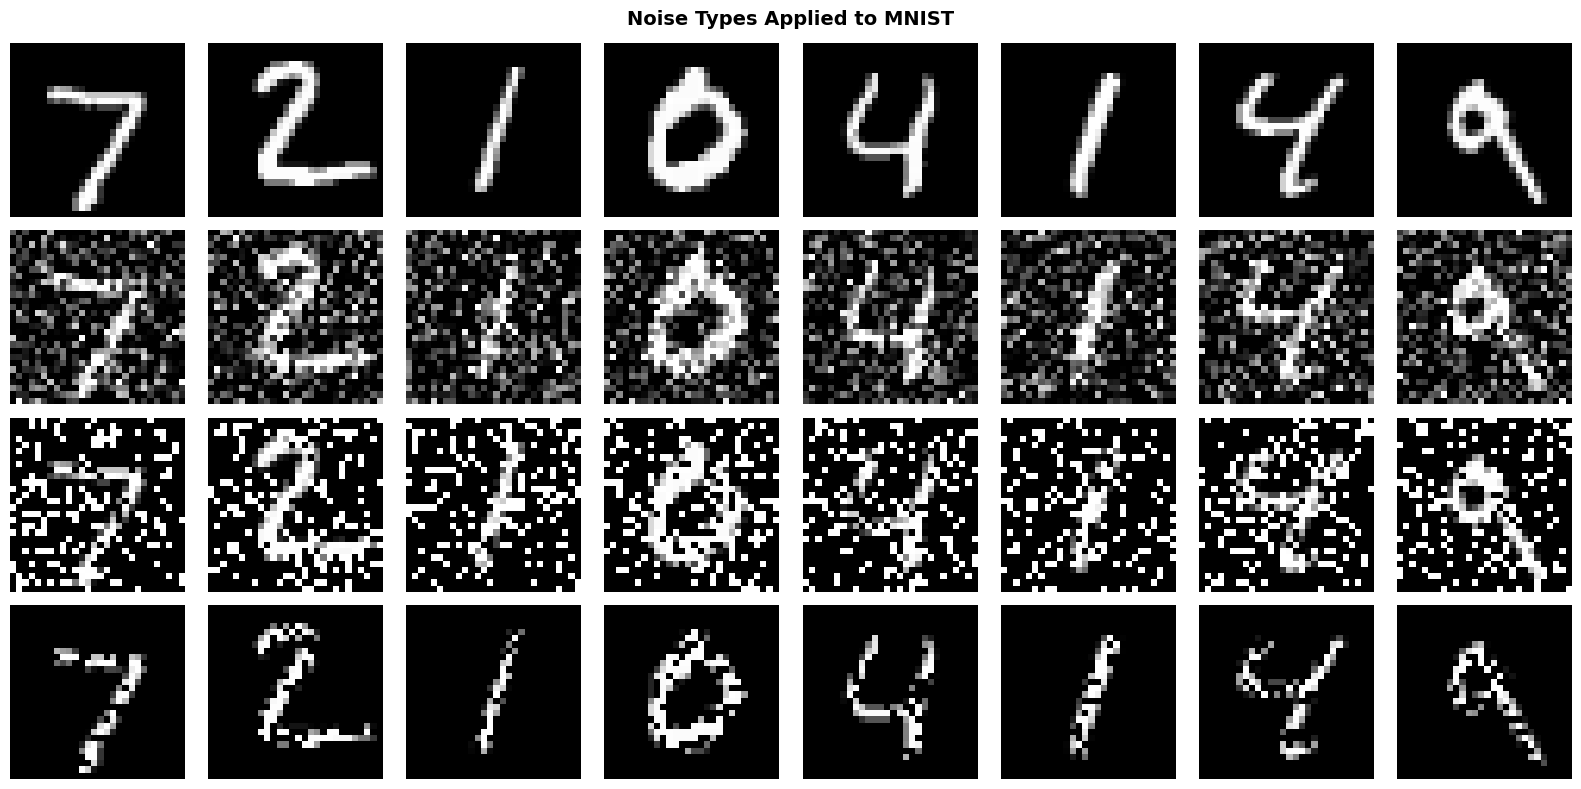

In [4]:
def add_noise(imgs, noise_type='gaussian', noise_factor=0.4):
    """
    Three noise types:
    - gaussian: add random Gaussian noise
    - salt_pepper: randomly set pixels to 0 or 1
    - masking: zero out random rectangular patches
    """
    noisy = imgs.clone()
    if noise_type == 'gaussian':
        noisy = noisy + noise_factor * torch.randn_like(noisy)
    elif noise_type == 'salt_pepper':
        mask = torch.rand_like(noisy)
        noisy[mask < noise_factor/2] = 0.0
        noisy[mask > 1 - noise_factor/2] = 1.0
    elif noise_type == 'masking':
        mask = (torch.rand_like(noisy) > noise_factor).float()
        noisy = noisy * mask
    return torch.clamp(noisy, 0., 1.)

# Visualize noise types
imgs, _ = next(iter(test_loader))
sample  = imgs[:8]

fig, axes = plt.subplots(4, 8, figsize=(16, 8))
for j in range(8):
    axes[0, j].imshow(sample[j].squeeze(), cmap='gray'); axes[0, j].axis('off')
    axes[1, j].imshow(add_noise(sample[j:j+1], 'gaussian')[0].squeeze(),    cmap='gray'); axes[1, j].axis('off')
    axes[2, j].imshow(add_noise(sample[j:j+1], 'salt_pepper')[0].squeeze(), cmap='gray'); axes[2, j].axis('off')
    axes[3, j].imshow(add_noise(sample[j:j+1], 'masking')[0].squeeze(),     cmap='gray'); axes[3, j].axis('off')

for ax, label in zip(axes[:, 0], ['Original', 'Gaussian', 'Salt & Pepper', 'Masking']):
    ax.set_ylabel(label, fontsize=12, fontweight='bold')

plt.suptitle('Noise Types Applied to MNIST', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('lab7_noise_types.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Autoencoder Design

In [5]:
class DenoisingAutoencoder(nn.Module):
    """
    Convolutional Denoising Autoencoder.
    Encoder: 28x28 → bottleneck (compressed representation)
    Decoder: bottleneck → 28x28 (reconstructed clean image)
    """
    def __init__(self, bottleneck_dim=64):
        super().__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),  nn.ReLU(), nn.MaxPool2d(2),  # 14x14
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # 7x7
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(),                   # 7x7
            nn.Flatten(),
            nn.Linear(128 * 7 * 7, bottleneck_dim), nn.ReLU()
        )
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck_dim, 128 * 7 * 7), nn.ReLU(),
            nn.Unflatten(1, (128, 7, 7)),
            nn.ConvTranspose2d(128, 64, 3, padding=1), nn.ReLU(),
            nn.Upsample(scale_factor=2),                                   # 14x14
            nn.ConvTranspose2d(64, 32, 3, padding=1),  nn.ReLU(),
            nn.Upsample(scale_factor=2),                                   # 28x28
            nn.ConvTranspose2d(32, 1, 3, padding=1),   nn.Sigmoid()
        )

    def forward(self, x):
        z     = self.encoder(x)
        recon = self.decoder(z)
        return recon, z

BOTTLENECK = 64   # 784 → 64 → 784  (compression ratio: 12.25x)
model      = DenoisingAutoencoder(bottleneck_dim=BOTTLENECK).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f'Model parameters: {total_params:,}')
print(f'Input dim:        784 (28x28)')
print(f'Bottleneck dim:   {BOTTLENECK}')
print(f'Compression ratio: {784/BOTTLENECK:.1f}x')

Model parameters: 994,369
Input dim:        784 (28x28)
Bottleneck dim:   64
Compression ratio: 12.2x


## 3. Training

In [6]:
NOISE_TYPE   = 'gaussian'
NOISE_FACTOR = 0.4
EPOCHS       = 20

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

train_losses, val_losses = [], []

for epoch in range(EPOCHS):
    # Training
    model.train()
    total = 0
    for imgs, _ in train_loader:
        imgs  = imgs.to(device)
        noisy = add_noise(imgs, NOISE_TYPE, NOISE_FACTOR).to(device)
        optimizer.zero_grad()
        recon, _ = model(noisy)
        loss = criterion(recon, imgs)  # reconstruct CLEAN image from NOISY input
        loss.backward()
        optimizer.step()
        total += loss.item()
    train_losses.append(total / len(train_loader))
    scheduler.step()

    # Validation
    model.eval()
    val_total = 0
    with torch.no_grad():
        for imgs, _ in test_loader:
            imgs  = imgs.to(device)
            noisy = add_noise(imgs, NOISE_TYPE, NOISE_FACTOR).to(device)
            recon, _ = model(noisy)
            val_total += criterion(recon, imgs).item()
    val_losses.append(val_total / len(test_loader))

    if (epoch+1) % 5 == 0:
        print(f'Epoch {epoch+1}/{EPOCHS} | Train MSE: {train_losses[-1]:.5f} | Val MSE: {val_losses[-1]:.5f}')

Epoch 5/20 | Train MSE: 0.11200 | Val MSE: 0.11430
Epoch 10/20 | Train MSE: 0.11200 | Val MSE: 0.11430
Epoch 15/20 | Train MSE: 0.11200 | Val MSE: 0.11430
Epoch 20/20 | Train MSE: 0.11201 | Val MSE: 0.11430


## 4. Reconstruction Quality

Noisy  MSE: 0.07968  | PSNR: 10.99 dB
Recon  MSE: 0.11430  | PSNR: 9.42 dB
PSNR improvement: +-1.57 dB


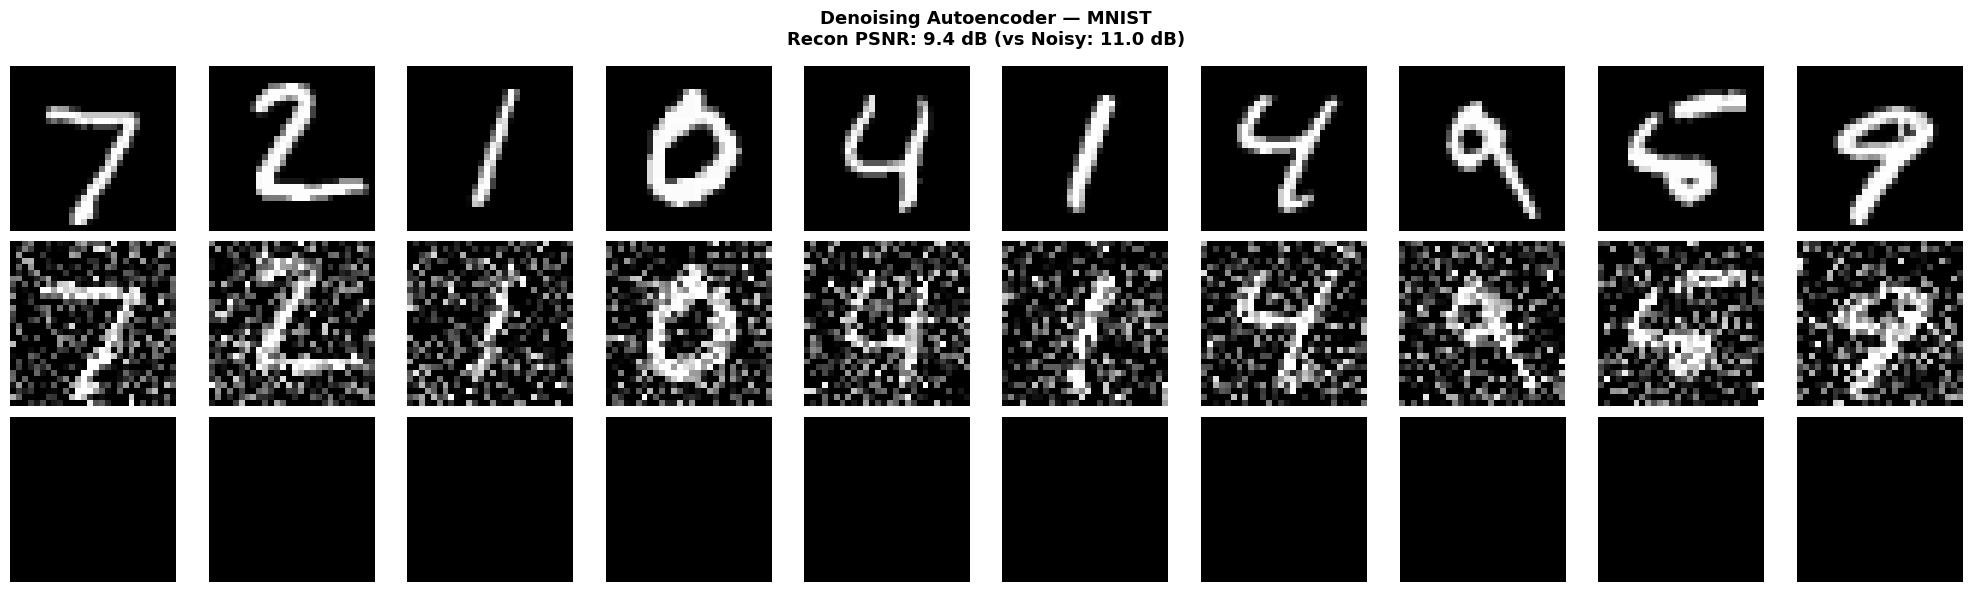

In [7]:
# Compute PSNR (Peak Signal-to-Noise Ratio) — quality metric
def psnr(mse, max_val=1.0):
    if mse == 0: return float('inf')
    return 20 * np.log10(max_val / np.sqrt(mse))

model.eval()
mse_noisy_list, mse_recon_list = [], []

with torch.no_grad():
    for imgs, _ in test_loader:
        imgs  = imgs.to(device)
        noisy = add_noise(imgs, NOISE_TYPE, NOISE_FACTOR).to(device)
        recon, _ = model(noisy)
        mse_noisy_list.append(F.mse_loss(noisy, imgs).item())
        mse_recon_list.append(F.mse_loss(recon, imgs).item())

mse_noisy = np.mean(mse_noisy_list)
mse_recon = np.mean(mse_recon_list)
print(f'Noisy  MSE: {mse_noisy:.5f}  | PSNR: {psnr(mse_noisy):.2f} dB')
print(f'Recon  MSE: {mse_recon:.5f}  | PSNR: {psnr(mse_recon):.2f} dB')
print(f'PSNR improvement: +{psnr(mse_recon) - psnr(mse_noisy):.2f} dB')

# Visual comparison
imgs, _   = next(iter(test_loader))
imgs      = imgs[:10].to(device)
noisy     = add_noise(imgs, NOISE_TYPE, NOISE_FACTOR)
with torch.no_grad():
    recon, _ = model(noisy)

fig, axes = plt.subplots(3, 10, figsize=(20, 6))
for j in range(10):
    axes[0, j].imshow(imgs[j].cpu().squeeze(),  cmap='gray'); axes[0, j].axis('off')
    axes[1, j].imshow(noisy[j].cpu().squeeze(), cmap='gray'); axes[1, j].axis('off')
    axes[2, j].imshow(recon[j].cpu().squeeze(), cmap='gray'); axes[2, j].axis('off')

for ax, label in zip(axes[:, 0], ['Original', f'Noisy ({NOISE_TYPE})', 'Reconstructed']):
    ax.set_ylabel(label, fontsize=11, fontweight='bold')

plt.suptitle(f'Denoising Autoencoder — MNIST\nRecon PSNR: {psnr(mse_recon):.1f} dB (vs Noisy: {psnr(mse_noisy):.1f} dB)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('lab7_reconstruction.png', dpi=150, bbox_inches='tight')
plt.show()

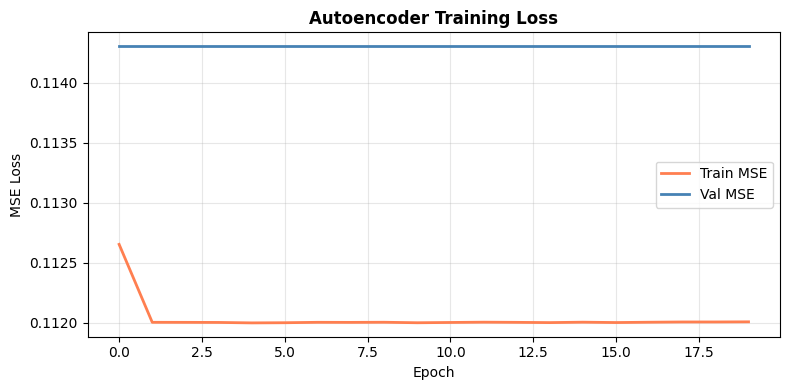

In [8]:
# Training curves
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train MSE', color='coral',     linewidth=2)
plt.plot(val_losses,   label='Val MSE',   color='steelblue', linewidth=2)
plt.title('Autoencoder Training Loss', fontweight='bold')
plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('lab7_loss.png', dpi=150)
plt.show()

## 5. Explanation of Compression

### Autoencoder Architecture
```
Input (784) → Encoder → Bottleneck (64) → Decoder → Output (784)
```
- **Encoder**: Compresses the input into a low-dimensional **latent code z** (bottleneck)
- **Bottleneck**: Forces the model to learn only the most essential features (12.25x compression)
- **Decoder**: Reconstructs the original from the compressed code

### Why Denoising Works
The DAE is trained on: `Input = noisy image → Target = clean image`.
To do this, the encoder must learn **which features are real signal vs noise**. Since noise is random and uncorrelated, it cannot be compressed efficiently — the bottleneck forces the model to discard it and keep only the structured digit features.

### Reconstruction Quality Metrics
| Metric | Formula | Interpretation |
|--------|---------|----------------|
| **MSE** | mean((pred - true)²) | Lower = better. Direct pixel error. |
| **PSNR** | 20·log₁₀(MAX/√MSE) | Higher = better (dB). > 30 dB is good quality. |

### Compression vs Quality Trade-off
| Bottleneck size | Compression | Quality |
|----------------|-------------|--------|
| 256 | 3x | Very high |
| 64  | 12x | High |
| 16  | 49x | Medium (blurry) |
| 2   | 392x | Low (shape only) |